In [1]:
import math, os
import time
import sys
sys.path.append("..")
sys.path.append("../experiments")

import torch
from spaVelo import SPAVELO
from spaVeloDenoise import SPAVELODenoise
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import h5py
import scanpy as sc
from preprocess_real import preprocess_data_real, get_init_variables

import pandas as pd
import scvelo as scv
import seaborn as sns
import matplotlib.pyplot as plt

import torch.nn.functional as F

import random

In [2]:
def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
def draw_velocity_stream(adata, spatial=False, color=None, xkey="pred_s", vkey="pred_velocity"):
    n_color = len(adata.obs[color].unique())
    if not spatial:
        scv.pp.neighbors(adata)
        # neighbors(adata, use_rep="X_pca")
        scv.tl.velocity_graph(adata, vkey=vkey, xkey=xkey)
        scv.pl.velocity_embedding_stream(adata, color=color, vkey=vkey, size=50, basis="umap", legend_loc="right", alpha=1)
    else:
        scv.pp.neighbors(adata, use_rep="X_coord")
        # neighbors(adata, use_rep="X_coord")
        scv.tl.velocity_graph(adata, vkey=vkey, xkey=xkey)
        scv.pl.velocity_embedding_stream(adata, color=color, vkey=vkey, basis="X_coord", size=50, legend_loc="right", alpha=1)
    plt.tight_layout()

## Config model Parameters
1. Set parameters for spaVelo
2. Load data and prepare directory for model outputs
3. Generate inducing points

In [4]:
class Config:
    def __init__(self):
        self.data_file = 'path_to_adata/stage57.h5ad'
        self.spliced_layer = 'spliced'
        self.unspliced_layer = 'unspliced'
        self.batch_size = 256
        self.maxiter = 5000
        self.train_size = 0.95
        self.patience = 100
        self.lr = 1e-3
        self.weight_decay = 1e-6
        self.dropoutE = 0.
        self.dropoutD = 0.
        self.encoder_layers = [256, 128]
        self.GP_dim = 2
        self.Normal_dim = 8
        self.decoder_layers = [128, 256]
        self.dynamicVAE = True
        self.init_beta = 4
        self.min_beta = 1
        self.max_beta = 25
        self.KL_loss = 0.025
        self.KL_weight = 15.
        self.penalty_scale = 10.
        self.n_samples = 1
        self.fix_inducing_points = True
        self.grid_inducing_points = True
        self.inducing_point_steps = 15
        self.inducing_point_nums = None
        self.fixed_gp_params = False
        self.loc_range = 20.
        self.w_latent_loss = 1.
        self.kernel_scale = 20.
        self.gene_selection = "spatial"
        self.use_raw = False
        self.no_rho = False
        self.save_dir = "../logs/real_data/" + time.strftime("%Y%m%d-%H%M%S", time.localtime())
        self.model_file = "model.pt"
        self.device = 'cuda:0'
args = Config()

In [5]:
set_seed(144)
os.makedirs(args.save_dir, exist_ok=True)
args.model_file = f"{args.save_dir}/{args.model_file}"
pd.Series(vars(args)).to_csv(f"{args.save_dir}/args.csv")
adata = sc.read_h5ad(args.data_file)

In [6]:
adata.obsm["X_coord_raw"] = adata.obsm["X_coord"].astype(np.float64)
scaler = MinMaxScaler()
adata.obsm["X_coord"] = scaler.fit_transform(adata.obsm["X_coord"]) * args.loc_range

In [7]:
if args.grid_inducing_points:
    eps = 1e-5
    initial_inducing_points = np.mgrid[0:(1+eps):(1./args.inducing_point_steps), 0:(1+eps):(1./args.inducing_point_steps)].reshape(2, -1).T * args.loc_range
    print(initial_inducing_points.shape)
else:
    loc = adata.obsm["X_coord"]
    loc_kmeans = KMeans(n_clusters=args.inducing_point_nums, n_init=100).fit(loc)
    np.savetxt(f"{args.save_dir}/location_centroids.txt", loc_kmeans.cluster_centers_, delimiter=",")
    np.savetxt(f"{args.save_dir}/location_kmeans_labels.txt", loc_kmeans.labels_, delimiter=",", fmt="%i")
    initial_inducing_points = loc_kmeans.cluster_centers_

(256, 2)


## Preprocess data

In [8]:
adata = preprocess_data_real(adata, spatial_layer="X_coord", spliced_layer=args.spliced_layer, unspliced_layer=args.unspliced_layer, dtype="float64", log_transform=True, min_max_scale=True, filter_on_r2=False, filter_on_ss=False, gene_selection=args.gene_selection, use_raw=args.use_raw, smooth_pca=False)
adata, us_upper, ms_upper, alpha_unconstr, gamma_unconstr, steady_beta_unconstr, steady_gamma_unconstr, alpha_1_unconstr, lambda_alpha_unconstr, prior_prob, gamma_r2 = get_init_variables(adata, spliced_layer=args.spliced_layer, unspliced_layer=args.unspliced_layer, gamma_init_data=False, dynamo_init=True)
adata.layers["prior_prob"] = prior_prob.argmax(axis=2)

  0%|          | 0/100 [00:00<?, ?/s]

/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 19 variables were constant, will return nan for these.
  warnings.warn(
/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 19 variables were constant, will return nan for these.
  warnings.warn(
/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 19 variables were constant, will return nan for these.
  warnings.warn(
/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 19 variables were constant, will return nan for these.
  warnings.warn(
/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 19 variables were constant, will return nan for these.
  warnings.warn(
/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packa

slected adata (4410, 2000)
Normalized count data: X, spliced, unspliced.
Logarithmized X.


/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing neighbors
    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


|-----> dynamics_del_2nd_moments_key is None. Using default value from DynamoAdataConfig: dynamics_del_2nd_moments_key=False
|-----------> removing existing M layers:[]...
|-----------> making adata smooth...
|-----> calculating first/second moments...
|-----> [moments calculation] completed [21.5861s]


estimating gamma: 100%|██████████| 2000/2000 [00:04<00:00, 430.15it/s]


## Initialize model

In [9]:
model = SPAVELODenoise(n_genes=adata.n_vars, true_time_switch=None, t_max=20, penalty_scale=args.penalty_scale, log_variational=False,
                GP_dim=args.GP_dim, Normal_dim=args.Normal_dim, encoder_layers=args.encoder_layers, decoder_layers=args.decoder_layers,
                encoder_dropout=args.dropoutE, decoder_dropout=args.dropoutD,
                fixed_inducing_points=args.fix_inducing_points, initial_inducing_points=initial_inducing_points, 
                fixed_gp_params=args.fixed_gp_params, kernel_scale=args.kernel_scale, N_train=adata.n_obs, KL_loss=args.KL_loss, dynamicVAE=args.dynamicVAE, 
                init_beta=args.init_beta, min_beta=args.min_beta, max_beta=args.max_beta, KL_weight=args.KL_weight,
                gamma_unconstr_init=gamma_unconstr, alpha_unconstr_init=alpha_unconstr, alpha_1_unconstr_init=alpha_1_unconstr,
                lambda_alpha_unconstr_init=lambda_alpha_unconstr, switch_spliced=ms_upper, switch_unspliced=us_upper, linear_decoder=False, 
                time_dep_transcription_rate=False, dirichlet_concentration=0.25, dtype=torch.float64, device=args.device, w_latent_loss=args.w_latent_loss, 
                use_raw=args.use_raw, adata=adata, spliced_layer=args.spliced_layer, unspliced_layer=args.unspliced_layer,
                use_rho=(not args.no_rho))


## Train model

In [10]:
model.train_model(adata, prior_prob=prior_prob, spatial_layer="X_coord", spliced_layer=args.spliced_layer, unspliced_layer=args.unspliced_layer,
        lr=args.lr, weight_decay=args.weight_decay, batch_size=args.batch_size, n_samples=args.n_samples,
        train_size=args.train_size, maxiter=args.maxiter, patience=args.patience, save_model=True, model_weights=args.model_file, log_dir=args.save_dir, gamma_r2=gamma_r2)

Computing velocity-based prior probabilities...
../logs/real_data/20260415-141120/model.pt
Training
Training epoch 1, ELBO:423.04541217, Reconstuction:-1459.32801952, End penalty:173.323130, GP KLD:0.06464717, PI KLD:136.98139776, Gaussian KLD:2.69111003
Current beta 4.806056077070563
Current kernel scale tensor([19.9908], device='cuda:0')
Training epoch 1, validating ELBO:195.88706425
Training epoch 2, ELBO:-873.41076463, Reconstuction:-2554.64537445, End penalty:150.514909, GP KLD:0.04158766, PI KLD:132.23737650, Gaussian KLD:7.47446682
Current beta 7.179623997055161
Current kernel scale tensor([19.9878], device='cuda:0')
Training epoch 2, validating ELBO:-1050.84703384
Training epoch 3, ELBO:-1615.14577623, Reconstuction:-3091.31987629, End penalty:129.552970, GP KLD:0.04313080, PI KLD:128.63465965, Gaussian KLD:6.10872813
Current beta 9.893712257663566
Current kernel scale tensor([19.9855], device='cuda:0')
Training epoch 3, validating ELBO:-1612.29648210
Training epoch 4, ELBO:-19

In [11]:
adata.layers["pred_velocity"] = model.get_velocity(adata, spatial_layer="X_coord", spliced_layer=args.spliced_layer, unspliced_layer=args.unspliced_layer,
                                                    batch_size=args.batch_size, n_samples=25)

## Draw velocity stream

computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/104 cores)


100%|██████████| 4410/4410 [00:06<00:00, 687.47cells/s]


    finished (0:00:06) --> added 
    'pred_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding


/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


    finished (0:00:00) --> added
    'pred_velocity_coord', embedded velocity vectors (adata.obsm)


/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/chensishuo/miniconda3/envs/spvelo/lib/python3.11/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/chensishuo/miniconda3/envs/spvelo/lib

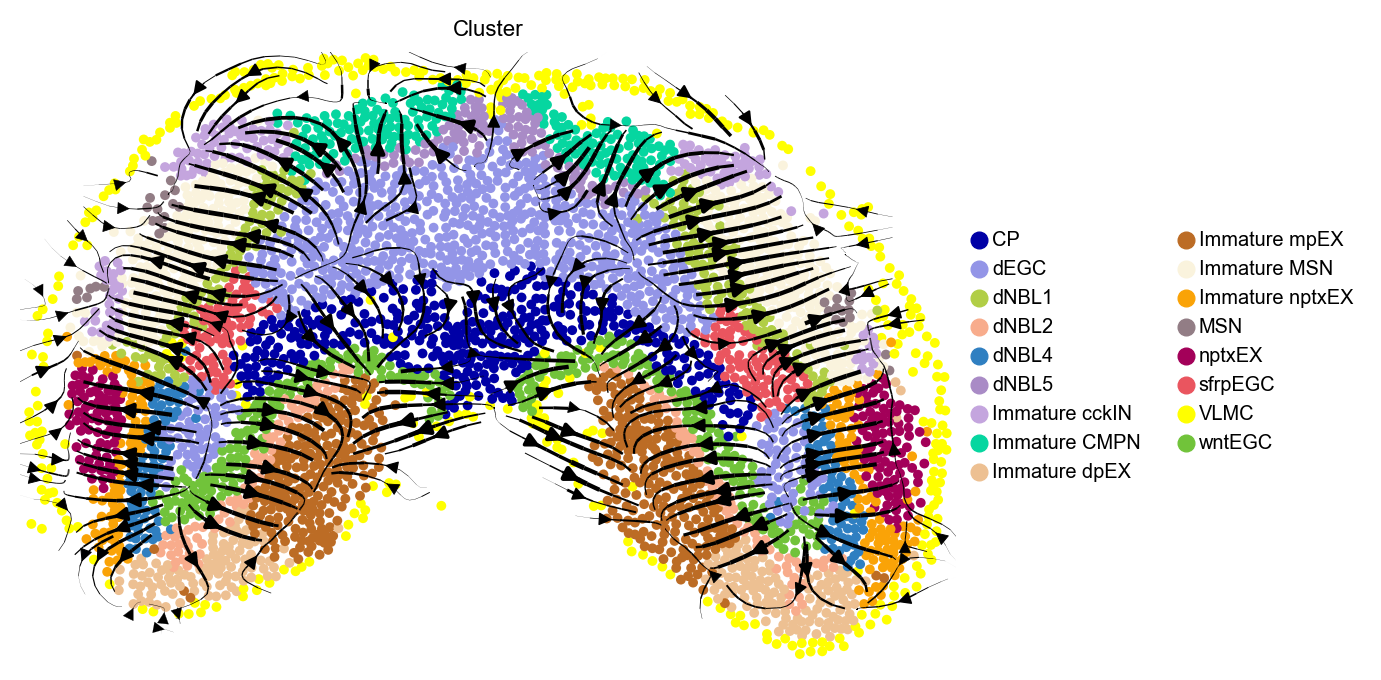

<Figure size 600x400 with 0 Axes>

In [12]:
draw_velocity_stream(adata.copy(), spatial=True, color="Cluster", xkey="Ms", vkey="pred_velocity")